In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import scipy.sparse as sp
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [4]:
meta = pd.read_csv("../../datasets/melanoma/RNA_metadata.csv")
meta = meta[meta["NAME"] != "TYPE"].copy() # drop type row
meta = meta.set_index("NAME")

meta.drop('library_preparation_protocol', axis=1, inplace=True)
meta.dropna(how='any', inplace=True)

meta["UMI_count"] = meta["UMI_count"].astype(float)
meta["MOI"] = meta["MOI"].astype(float)

#ensured only 1 guide
meta = meta[meta['MOI'] == 1].copy()


#normalize replicate guides
sgRNA = meta['sgRNA'].values
meta['sgRNA'] = np.array(["_".join(s.split('_')[:-1]) for s in sgRNA], dtype=object)

meta = meta[meta['sgRNA'] != 'ONE_NON-GENE_SITE'].copy()

meta

/var/tmp/ipykernel_1779176/4076620681.py:1: DtypeWarning: Columns (3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("../../datasets/melanoma/RNA_metadata.csv")


,condition,MOI,sgRNA,UMI_count
NAME,,,,
CELL_1,Control,1.0,HLA-B,10832.0
CELL_3,Control,1.0,HLA-B,28821.0
CELL_6,Control,1.0,IFNGR1,8810.0
CELL_8,Control,1.0,CDKN1A,8491.0
CELL_9,Control,1.0,EMP1,7478.0
...,...,...,...,...
CELL_218323,Co-culture,1.0,SLC22A18,15823.0
CELL_218325,Co-culture,1.0,SLC19A1,30696.0
CELL_218326,Co-culture,1.0,AHNAK,16010.0


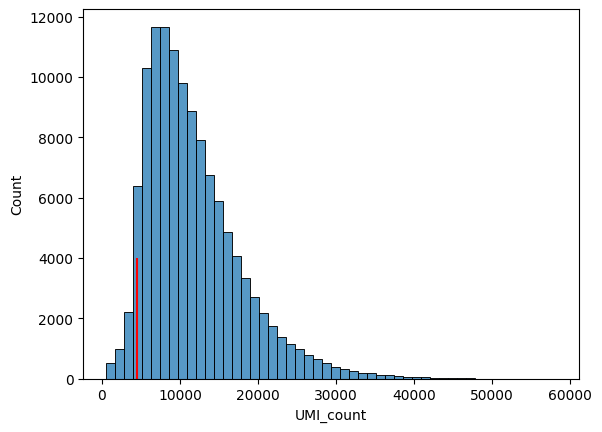

In [5]:
sns.histplot(meta['UMI_count'], bins=50)
percentile_filter = np.percentile(meta['UMI_count'], 5)
plt.vlines(percentile_filter, 0, 4000, color='red')

In [6]:
meta = meta[meta['UMI_count'] >= np.percentile(meta['UMI_count'], 5)].copy()

<Axes: xlabel='count', ylabel='Count'>

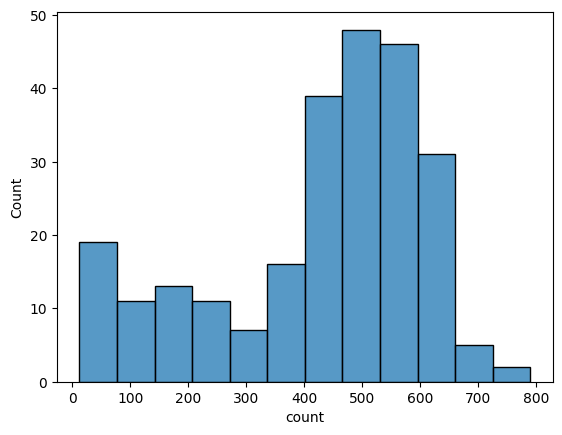

In [7]:
sns.histplot(meta[meta['sgRNA'] != 'NO_SITE']['sgRNA'].value_counts())
# plt.vlines(300, 0, 50)

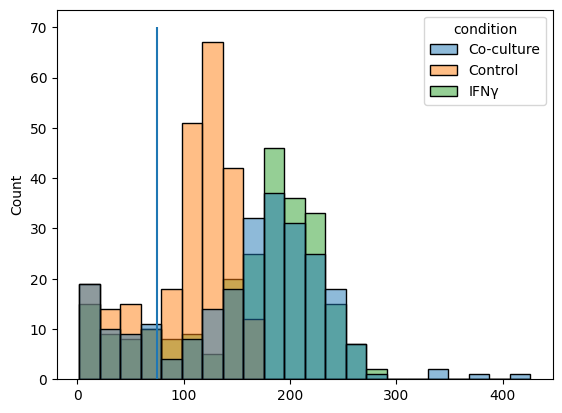

In [8]:
cells_per_pert_cond = (
    meta.groupby(['sgRNA', 'condition']).size().unstack(fill_value=0).astype(int)
)
# cells_per_pert_cond = (
#     cells_per_pert_cond.assign(_total=cells_per_pert_cond.sum(axis=1))
#     .sort_values('_total', ascending=False)
# )
sns.histplot(cells_per_pert_cond[cells_per_pert_cond.index != 'NO_SITE'])
pert_cutoff = 75
plt.vlines(pert_cutoff, 0, 70)


In [9]:
# keep sgRNAs meeting the cutoff in EVERY condition
keep_mask = (cells_per_pert_cond >= pert_cutoff).all(axis=1)
keep_sgrnas = cells_per_pert_cond.index[keep_mask]

meta = meta[meta['sgRNA'].isin(keep_sgrnas)].copy()

print(f"Kept {keep_mask.sum()} of {cells_per_pert_cond.shape[0]} sgRNAs (≥{pert_cutoff} in every condition).")
print(f"Kept {meta.shape[0]} of {meta.shape[0]} rows in meta.")

Kept 194 of 249 sgRNAs (≥75 in every condition).
Kept 107167 of 107167 rows in meta.


In [10]:
adata = ad.io.read_csv("../../datasets/melanoma/RNA_expression.csv.gz")

In [32]:
adata = adata.T
common = adata.obs_names.intersection(meta.index)

adata = adata[common].copy()
meta_aligned = meta.loc[common].copy()

adata.obs = adata.obs.join(meta_aligned)

adata.X = sp.csr_matrix(adata.X)

In [52]:
adata.X = np.expm1(adata.X.toarray())

libsize = meta["UMI_count"].to_numpy()
scale = libsize / 1e6  # per-cell scaling factor

adata.X = (adata.X * scale[:, None]).astype(np.float32)

adata.X = np.rint(adata.X)

In [58]:
adata.obs['library_size'] = adata.X.sum(axis=1)

<Axes: xlabel='library_size', ylabel='Count'>

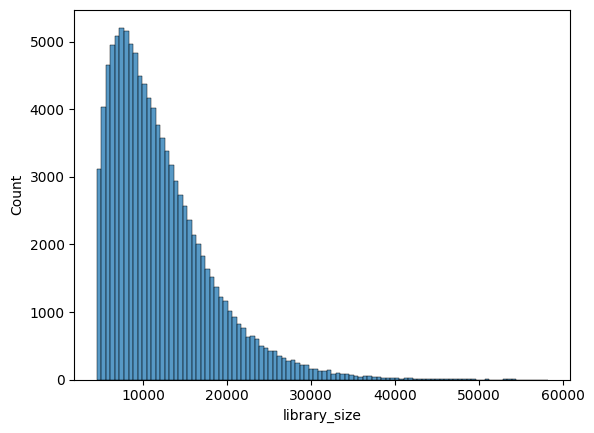

In [59]:
sns.histplot(adata.obs['library_size'], bins=100)

In [57]:
adata.X = sp.csr_matrix(adata.X)

In [61]:
ad.io.write_h5ad("../../datasets/melanoma/RNA_expression.h5ad", adata)

In [62]:
adata.layers['counts'] = adata.X.copy()

In [63]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)

sc.tl.umap(adata)

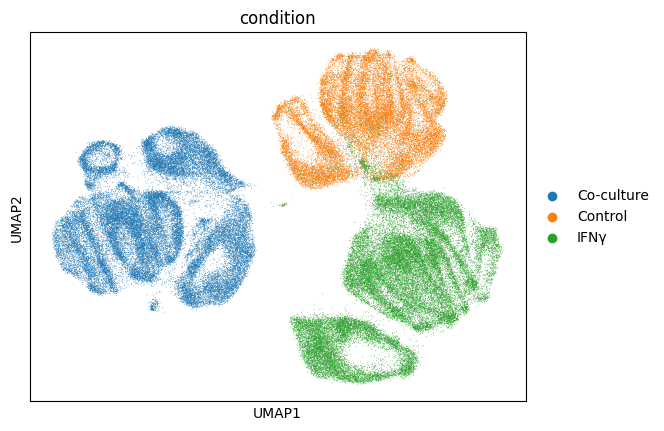

In [64]:
sc.pl.umap(adata, color=['condition'])

In [ ]:
ad.io.write_h5ad("../../datasets/melanoma/melanoma_preprocessed.h5ad", adata)

In [3]:
adata = sc.read_h5ad("../../datasets/melanoma/melanoma_preprocessed.h5ad")

In [8]:
adata_ctrl = adata[adata.obs["condition"] == "Control"]

print("Computing DEGs for sgRNA vs NO_SITE within Control condition...")
sc.tl.rank_genes_groups(
    adata_ctrl,
    groupby="sgRNA",
    reference="NO_SITE",
    method="wilcoxon",
    n_genes=20         
)

df_sgrna = sc.get.rank_genes_groups_df(adata_ctrl, group=None)
df_sgrna = df_sgrna[df_sgrna["group"] != "NO_SITE"]
top_genes_sgrna = df_sgrna["names"].unique()


adata_ntc = adata[adata.obs["sgRNA"] == "NO_SITE"]

print("Computing DEGs for condition vs Control within NO_SITE sgRNA...")
sc.tl.rank_genes_groups(
    adata_ntc,
    groupby="condition",
    reference="Control",
    method="wilcoxon",
    n_genes=20         
)

df_cond = sc.get.rank_genes_groups_df(adata_ntc, group=None)
df_cond = df_cond[df_cond["group"] != "Control"]
top_genes_cond = df_cond["names"].unique()



union_genes = np.unique(np.concatenate([top_genes_sgrna, top_genes_cond]))
adata.var["use_gene"] = adata.var_names.isin(union_genes)

Computing DEGs for sgRNA vs NO_SITE within Control condition...


/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/conda/envs/perturb/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 

Computing DEGs for condition vs Control within NO_SITE sgRNA...


In [11]:
ad.io.write_h5ad("../../datasets/melanoma/melanoma_preprocessed.h5ad", adata)